I KOMANG WISNU AMBARA | 2301020085

Dataset:
https://docs.google.com/spreadsheets/d/1wOicKVm_xbG8cXg9pW8YeTByCHto0uRh/edit?usp=sharing&ouid=114157221880512369704&rtpof=true&sd=true

Sumber: https://www.kaggle.com/datasets/wisnuanggara/daftar-harga-rumah?resource=download

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [ ]:
from google.colab import files
uploaded = files.upload()

df = pd.read_excel('DATA RUMAH.xlsx')
df.head()

Saving DATA RUMAH.xlsx to DATA RUMAH.xlsx


,NO,NAMA RUMAH,HARGA,LB,LT,KT,KM,GRS
0,1,"Rumah Murah Hook Tebet Timur, Tebet, Jakarta S...",3800000000,220,220,3,3,0
1,2,"Rumah Modern di Tebet dekat Stasiun, Tebet, Ja...",4600000000,180,137,4,3,2
2,3,"Rumah Mewah 2 Lantai Hanya 3 Menit Ke Tebet, T...",3000000000,267,250,4,4,4
3,4,"Rumah Baru Tebet, Tebet, Jakarta Selatan",430000000,40,25,2,2,0
4,5,"Rumah Bagus Tebet komp Gudang Peluru lt 350m, ...",9000000000,400,355,6,5,3


In [ ]:
print("Jumlah data:", df.shape)
df.info()
df.describe()

Jumlah data: (1010, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1010 entries, 0 to 1009
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   NO          1010 non-null   int64 
 1   NAMA RUMAH  1010 non-null   object
 2   HARGA       1010 non-null   int64 
 3   LB          1010 non-null   int64 
 4   LT          1010 non-null   int64 
 5   KT          1010 non-null   int64 
 6   KM          1010 non-null   int64 
 7   GRS         1010 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 63.3+ KB


,NO,HARGA,LB,LT,KT,KM,GRS
count,1010.000000,1.010000e+03,1010.000000,1010.000000,1010.000000,1010.000000,1010.000000
mean,505.500000,7.628987e+09,276.539604,237.432673,4.668317,3.607921,1.920792
std,291.706188,7.340946e+09,177.864557,179.957604,1.572776,1.420066,1.510998
min,1.000000,4.300000e+08,40.000000,25.000000,2.000000,1.000000,0.000000
25%,253.250000,3.262500e+09,150.000000,130.000000,4.000000,3.000000,1.000000
50%,505.500000,5.000000e+09,216.500000,165.000000,4.000000,3.000000,2.000000
75%,757.750000,9.000000e+09,350.000000,290.000000,5.000000,4.000000,2.000000
max,1010.000000,6.500000e+10,1126.000000,1400.000000,10.000000,10.000000,10.000000


In [ ]:
df = df.drop(columns=['NO', 'NAMA RUMAH'])
print(df.isnull().sum())
df = df.dropna()

HARGA    0
LB       0
LT       0
KT       0
KM       0
GRS      0
dtype: int64


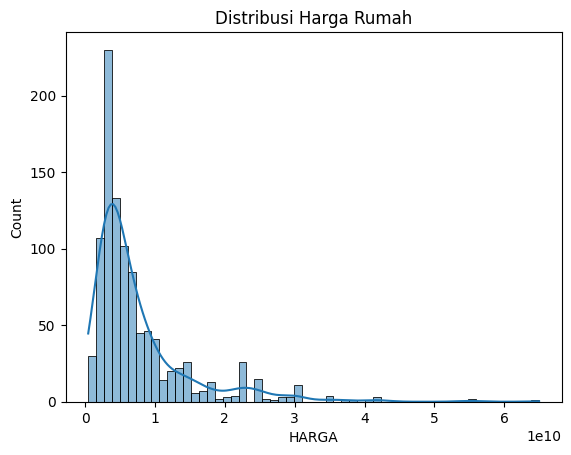

In [ ]:
plt.figure()
sns.histplot(df['HARGA'], kde=True)
plt.title('Distribusi Harga Rumah')
plt.show()

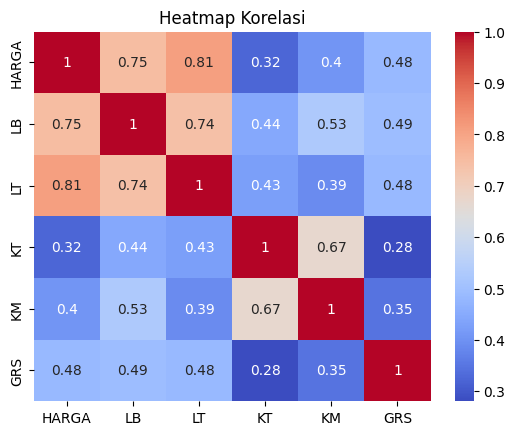

In [ ]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

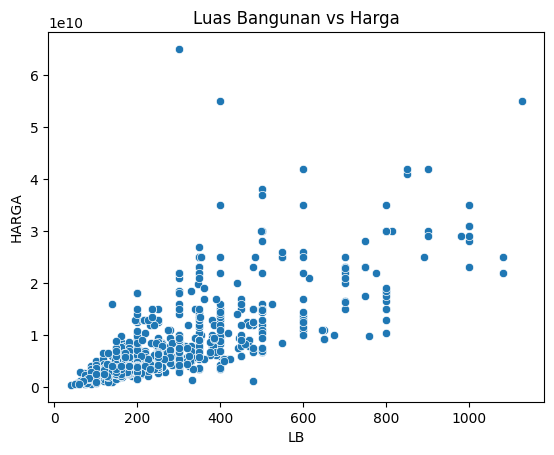

In [ ]:
plt.figure()
sns.scatterplot(x=df['LB'], y=df['HARGA'])
plt.title('Luas Bangunan vs Harga')
plt.show()

In [ ]:
df['TOTAL_LUAS'] = df['LB'] + df['LT']

In [ ]:
X = df[['LB', 'LT', 'KT', 'KM', 'GRS', 'TOTAL_LUAS']]
y = df['HARGA']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_simple = df[['LB']]
y_simple = df['HARGA']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train_s)

y_pred_s = model_simple.predict(X_test_s)

In [ ]:
mae_s = mean_absolute_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mean_squared_error(y_test_s, y_pred_s))
r2_s = r2_score(y_test_s, y_pred_s)

print("Simple Regression:")
print("MAE:", mae_s)
print("RMSE:", rmse_s)
print("R2:", r2_s)

Simple Regression:
MAE: 2803890706.9528036
RMSE: 4336509029.972495
R2: 0.5971684159137438


In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)

y_pred = model_multi.predict(X_test_scaled)

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nMultiple Regression:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


Multiple Regression:
MAE: 1980345761.1519244
RMSE: 3267373421.2754784
R2: 0.7713134894077547


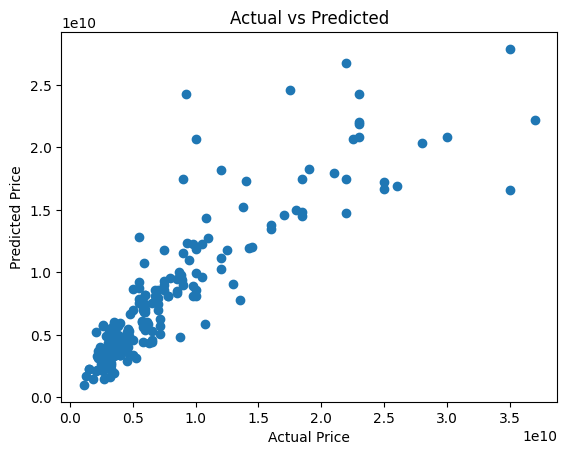

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

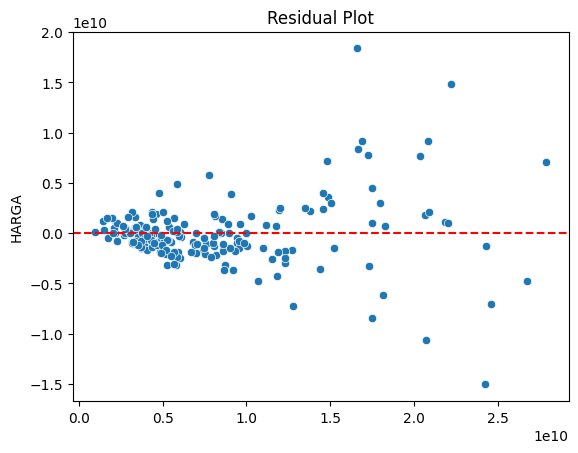

In [ ]:
residuals = y_test - y_pred

plt.figure()
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title("Residual Plot")
plt.show()

In [ ]:
print("Perbandingan Model:")
print("Linear R2:", r2_s)
print("Multiple R2:", r2)

Perbandingan Model:
Linear R2: 0.5971684159137438
Multiple R2: 0.7713134894077547
